# Main notebook

### Init

In [130]:
# git add .
# git commit -m "message"
# git push origin main


%load_ext autoreload
%autoreload 2

from pathlib import Path
import pandas as pd
import numpy as np

from src.data.data import load_data, print_mol_types, featurize
from src.data.preprocess import keep_largest, salt_remover, preprocess, preprocess_conc
from src.utils.plotting import plot_smiles, plot_metals, plot_training
from src.model.eval import train, predict

from rdkit import Chem
from rdkit.Chem.SaltRemover import SaltRemover
from rdkit.Chem import AllChem, Draw, PandasTools, Descriptors
from rdkit.Chem.rdmolops import GetAdjacencyMatrix
from rdkit.Chem.Draw import IPythonConsole

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Init data

In [131]:
path = Path("Data") / "toxicity_fish.csv"
selected_columns = ["SMILES", "conc"]
cut = 200
# cut = None

df = load_data(path, selected_columns, cut)

print(df.head())
print("")
print_mol_types(df)

       SMILES  conc
0  O=[O+][O-]  0.18
1  O=[O+][O-]  0.18
2  O=[O+][O-]  0.26
3  O=[O+][O-]  0.26
4  O=[O+][O-]  0.17

Total molecules: 200
Unique molecules: 29
Salts: 83, 41.50%
Single atoms: 6, 3.00%
Metals: 65, 32.50%


### Data analysis

       SMILES  conc
0  O=[O+][O-]  0.18
1  O=[O+][O-]  0.18
2  O=[O+][O-]  0.26
3  O=[O+][O-]  0.26
4  O=[O+][O-]  0.17


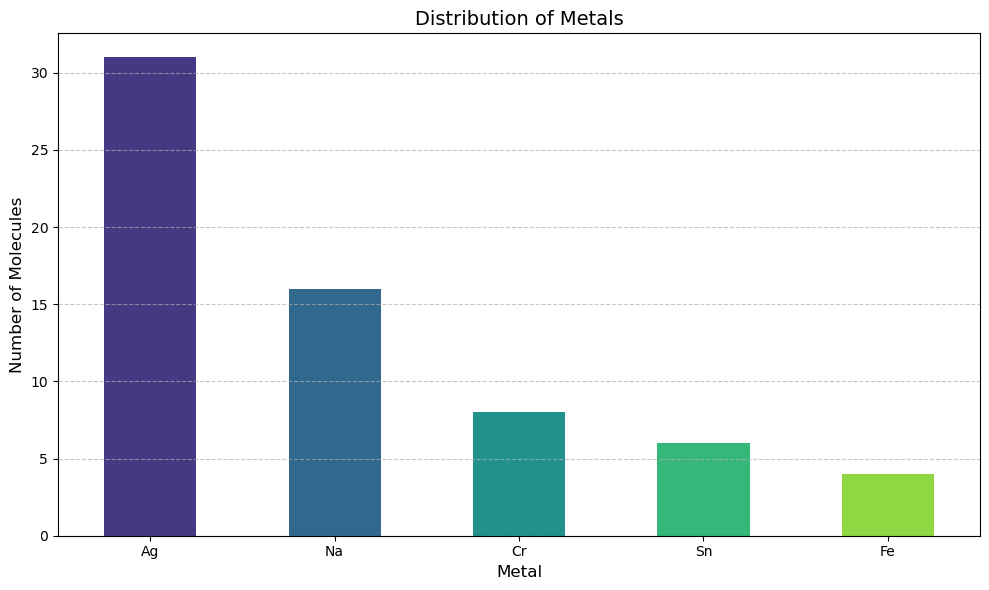

In [132]:
# Mol types and metals

mol_id = 16
print(df.head())

plot_metals(df)

### Data processing

In [133]:
# Preprocess by splitting salts, removing lone atoms and removing metals, also converting concentrations to log scale
df_pp = preprocess(df, split_salts=True, remove_lone=False, remove_metals=False)

print(df_pp.head())
print("")
print_mol_types(df_pp)

       SMILES      conc
0  O=[O+][O-] -0.744727
1  O=[O+][O-] -0.744727
2  O=[O+][O-] -0.585027
3  O=[O+][O-] -0.585027
4  O=[O+][O-] -0.769551

Total molecules: 200
Unique molecules: 29
Salts: 0, 0.00%
Single atoms: 6, 3.00%
Metals: 49, 24.50%


In [134]:
# df["conc"] = df["conc"].apply(lambda x: preprocess_conc(x))
df["log10c"] = df["conc"].apply(lambda x: np.log10(x))
print(df.head())

       SMILES      conc  log10c
0  O=[O+][O-] -0.744727     NaN
1  O=[O+][O-] -0.744727     NaN
2  O=[O+][O-] -0.585027     NaN
3  O=[O+][O-] -0.585027     NaN
4  O=[O+][O-] -0.769551     NaN


/tmp/ipykernel_4147891/3725229983.py:2: RuntimeWarning: invalid value encountered in log10
  df["log10c"] = df["conc"].apply(lambda x: np.log10(x))


### PyG

In [135]:
from torch_geometric.utils.smiles import from_smiles

# Featurize the data
df["features"] = df["SMILES"].apply(lambda x: from_smiles(x))

print(df["features"][0])
print("")
print(df.head())
print("")
print(f"Length of dataset: {len(df)}")

Data(x=[3, 9], edge_index=[2, 4], edge_attr=[4, 3], smiles='O=[O+][O-]')

       SMILES      conc  log10c  \
0  O=[O+][O-] -0.744727     NaN   
1  O=[O+][O-] -0.744727     NaN   
2  O=[O+][O-] -0.585027     NaN   
3  O=[O+][O-] -0.585027     NaN   
4  O=[O+][O-] -0.769551     NaN   

                                            features  
0  [(x, [tensor([8, 0, 1, 5, 0, 0, 3, 0, 0]), ten...  
1  [(x, [tensor([8, 0, 1, 5, 0, 0, 3, 0, 0]), ten...  
2  [(x, [tensor([8, 0, 1, 5, 0, 0, 3, 0, 0]), ten...  
3  [(x, [tensor([8, 0, 1, 5, 0, 0, 3, 0, 0]), ten...  
4  [(x, [tensor([8, 0, 1, 5, 0, 0, 3, 0, 0]), ten...  

Length of dataset: 200


In [6]:
import deepchem as dc

featurizer = dc.feat.MolGraphConvFeaturizer(use_edges=True)
X, df = featurize(df_pp, featurizer, apply_filter=True)
len(X)

Failed to featurize datapoint 143, [NH4+]. Appending empty array
Exception message: More than one atom should be present in the molecule for this featurizer to work.
Failed to featurize datapoint 144, [NH4+]. Appending empty array
Exception message: More than one atom should be present in the molecule for this featurizer to work.
Exception message: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (145,) + inhomogeneous part.



Org size: 145, Filtered size: 143


143

In [7]:
mol_id = 16

print(type(X[mol_id]))

print(X[mol_id])
print("")
# node_features: n_atoms x n_node_features (feature length = 30)
# - Atom type, formal charge, hybridization, hydrogen bonding, aromatic, degree, n_hydrogens, chirality, partial charge
print("Node features for one atom example:")
print(X[mol_id].node_features[2])
# edge_index: 2 x n_edges (source and target) - shows bonds
# edge_features: n_edges x n_edge_features (feature length = 11)
# - Bond type, same ring, conjugated, stereo
print("Edge features for one bond example:")
print(X[mol_id].edge_features[2])

<class 'deepchem.feat.graph_data.GraphData'>
GraphData(node_features=[9, 30], edge_index=[2, 18], edge_features=[18, 11])

Node features for one atom example:
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.
 0. 1. 0. 0. 0. 0.]
Edge features for one bond example:
[0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0.]


In [8]:
# Create a dataset
dataset = dc.data.NumpyDataset(X=X, y=df['conc'].values, ids=df['SMILES'])

# print(dataset)

# Split dataset
splitter = dc.splits.ScaffoldSplitter() # Scaffold splitter puts similar molecules in the same dataset
train_dataset, test_dataset = splitter.train_test_split(dataset, seed=42)

print(f"Train set size: {len(train_dataset)} - {len(train_dataset) / len(dataset) * 100:.2f}%")
print(f"Test set size: {len(test_dataset)} - {len(test_dataset) / len(dataset) * 100:.2f}%")

Train set size: 105 - 73.43%
Test set size: 38 - 26.57%


# GNN

In [9]:
from deepchem.models.torch_models import GCNModel
import dgl
import torch

# GCNModel for regression (predicting concentration)
model = GCNModel(
    n_tasks=1,
    mode='regression',
    learning_rate=0.001,
    batch_size=16
)

lessgo4
Epoch 0: Train Loss = 1.2954510280064173, Test Loss = 1.13145957289692
Epoch 10: Train Loss = 0.2512803588594709, Test Loss = 1.0485991491218571
Epoch 20: Train Loss = 0.15483570098876953, Test Loss = 1.0681704704302986
Epoch 30: Train Loss = 0.17987801347460067, Test Loss = 0.5373834723943867
Epoch 40: Train Loss = 0.12153947353363037, Test Loss = 0.5202593949011022
Epoch 50: Train Loss = 0.11944189241954259, Test Loss = 0.48475358661360485
Epoch 60: Train Loss = 0.09801668780190605, Test Loss = 0.643910917952396
Epoch 70: Train Loss = 0.11176970175334386, Test Loss = 0.5445709405462476
Epoch 80: Train Loss = 0.13573414087295532, Test Loss = 0.4954752406945026
Epoch 90: Train Loss = 0.14079112665993826, Test Loss = 0.5914785832094301
Training complete: Train Loss = 0.18394412313188827


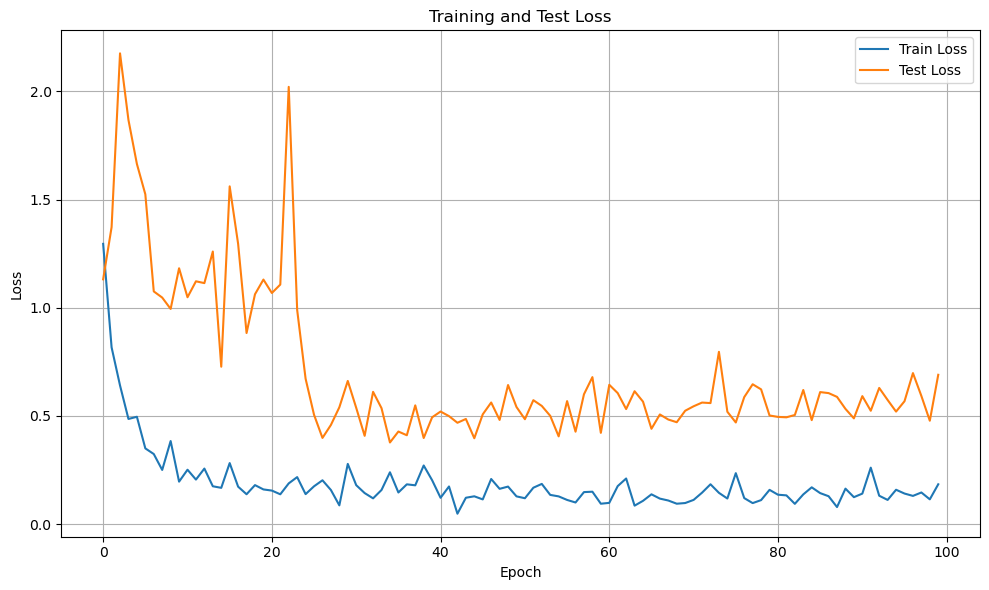

In [10]:
loss_fn = torch.nn.MSELoss()

train_losses, test_losses = train(model, train_dataset, test_dataset, loss_fn=loss_fn, epochs=100)

plot_training(train_losses, test_losses)